In [31]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [33]:
train_df = pd.read_csv('data/청구정보_with_segment.csv')

In [3]:
train_df.info()
train_df.describe()
train_df.isnull().sum()
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 47 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   기준년월              int64 
 1   ID                object
 2   대표결제일             int64 
 3   대표결제방법코드          object
 4   대표청구지고객주소구분코드     object
 5   대표청구서수령지구분코드      object
 6   청구서수령방법           object
 7   청구서발송여부_B0        int64 
 8   청구서발송여부_R3M       int64 
 9   청구서발송여부_R6M       int64 
 10  청구금액_B0           int64 
 11  청구금액_R3M          int64 
 12  청구금액_R6M          int64 
 13  포인트_마일리지_건별_B0M   int64 
 14  포인트_마일리지_건별_R3M   int64 
 15  포인트_포인트_건별_B0M    int64 
 16  포인트_포인트_건별_R3M    int64 
 17  포인트_마일리지_월적립_B0M  int64 
 18  포인트_마일리지_월적립_R3M  int64 
 19  포인트_포인트_월적립_B0M   int64 
 20  포인트_포인트_월적립_R3M   int64 
 21  포인트_적립포인트_R12M    int64 
 22  포인트_적립포인트_R3M     int64 
 23  포인트_이용포인트_R12M    int64 
 24  포인트_이용포인트_R3M     int64 
 25  포인트_잔여포인트_B0M     int64 
 26  마일_적립포인트_R12M     int64 
 27  마일_적립포인트_R3M

,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,청구서발송여부_R6M,...,상환개월수_결제일_R6M,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액,Segment
0,201807,TRAIN_000000,27,자동이체,미확인,당사페이앱+이메일,문자메세지,1,1,1,...,5,3,0,0,1,0,3,0,0,D
1,201807,TRAIN_000001,13,자동이체,주거지,우편,우편,1,1,1,...,6,3,0,0,0,0,0,0,0,E
2,201807,TRAIN_000002,1,자동이체,미확인,이메일,이메일,1,1,1,...,6,3,0,0,0,0,121,0,50,C
3,201807,TRAIN_000003,5,자동이체,주거지,우편,우편,1,1,1,...,5,3,2,0,0,0,3,0,2,D
4,201807,TRAIN_000004,13,자동이체,주거지,우편,우편,0,1,1,...,1,1,0,0,0,0,0,0,0,E


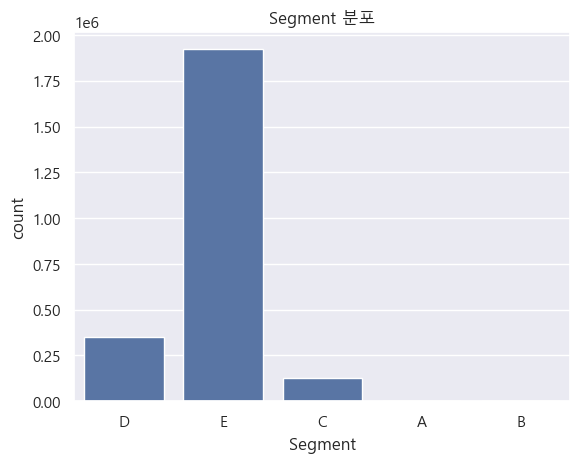

In [4]:
sns.countplot(data=train_df, x='Segment')
plt.title('Segment 분포')
plt.show()

In [5]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

<Axes: xlabel='Segment', ylabel='혜택수혜금액_R3M'>

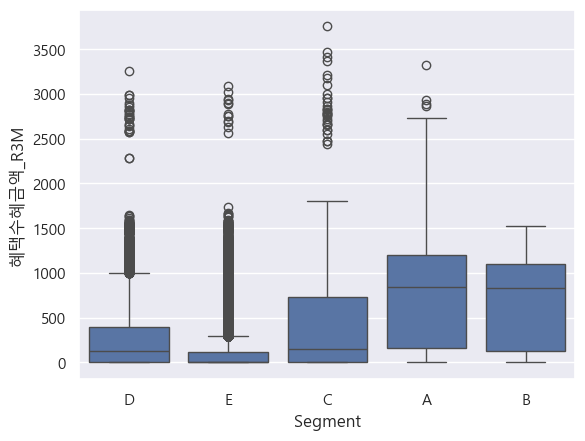

In [6]:
sns.boxplot(data=train_df, x='Segment', y='혜택수혜금액_R3M')

<Axes: xlabel='청구서발송여부_B0', ylabel='count'>

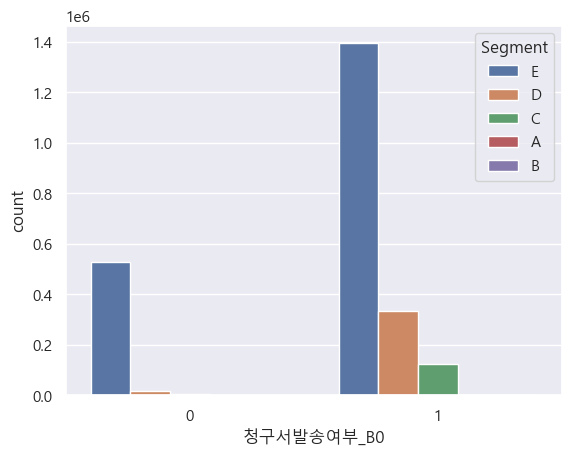

In [7]:
sns.countplot(data=train_df, x='청구서발송여부_B0', hue='Segment')

In [8]:
from sklearn.preprocessing import LabelEncoder

train_df2 = train_df.copy()
le = LabelEncoder()
train_df2['Segment_encoded'] = le.fit_transform(train_df2['Segment'])


In [9]:
numeric_cols = train_df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_series = train_df2[numeric_cols].corrwith(train_df2['Segment_encoded']).sort_values(key=abs, ascending=False)
display(corr_series.head(20))


청구금액_R6M           -0.597904
청구금액_R3M           -0.590678
청구금액_B0            -0.577988
혜택수혜금액_R3M         -0.355754
혜택수혜금액             -0.350857
포인트_마일리지_환산_B0M    -0.281306
마일_적립포인트_R3M       -0.276183
포인트_마일리지_건별_R3M    -0.216643
포인트_마일리지_건별_B0M    -0.214917
마일_적립포인트_R12M      -0.213707
마일_이용포인트_R3M       -0.213142
마일_이용포인트_R12M      -0.212008
청구서발송여부_B0         -0.209534
할인금액_청구서_R3M       -0.202703
할인금액_청구서_B0M       -0.196683
청구서발송여부_R3M        -0.187036
할인금액_R3M           -0.185652
마일_잔여포인트_B0M       -0.183546
포인트_마일리지_월적립_R3M   -0.180634
할인금액_B0M           -0.180181
dtype: float64

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1) + 1e-10)))

cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Segment']

cramer_dict = {}
for col in cat_cols:
    try:
        cramer_dict[col] = cramers_v(train_df[col], train_df['Segment'])
    except:
        cramer_dict[col] = np.nan

cramer_series = pd.Series(cramer_dict).sort_values(ascending=False)
display(cramer_series.head(10))


ID               1.000000
할인건수_R3M         0.132951
할인건수_B0M         0.095100
대표청구지고객주소구분코드    0.063806
대표청구서수령지구분코드     0.048989
청구서수령방법          0.048988
대표결제방법코드         0.000000
dtype: float64

In [11]:
# 예: 수치형 중 절댓값 기준 0.2 이상
high_corr_num = corr_series[abs(corr_series) > 0.2].index.tolist()

# 범주형 중 Cramér’s V 기준 0.2 이상
high_corr_cat = cramer_series[cramer_series > 0.2].index.tolist()

# 최종 관심 컬럼
important_cols = high_corr_num + high_corr_cat
print("Segment와 관련 높은 컬럼:")
print(important_cols)


Segment와 관련 높은 컬럼:
['청구금액_R6M', '청구금액_R3M', '청구금액_B0', '혜택수혜금액_R3M', '혜택수혜금액', '포인트_마일리지_환산_B0M', '마일_적립포인트_R3M', '포인트_마일리지_건별_R3M', '포인트_마일리지_건별_B0M', '마일_적립포인트_R12M', '마일_이용포인트_R3M', '마일_이용포인트_R12M', '청구서발송여부_B0', '할인금액_청구서_R3M', 'ID']


In [12]:
results = []

for col in train_df2.columns:
    if col in ['Segment', 'Segment_encoded']:
        continue  # 타겟은 제외
    
    dtype = train_df2[col].dtype
    var_type = '수치형' if dtype in ['int64', 'float64'] else '범주형'

    # 상관계수 (수치형만 계산 가능)
    try:
        corr = train_df2[[col, 'Segment_encoded']].corr().iloc[0, 1] if var_type == '수치형' else None
    except:
        corr = None

    results.append({
        '컬럼명': col,
        '변수 타입': var_type,
        'Segment 상관계수': corr
    })

# 정렬 및 출력
result_df = pd.DataFrame(results).sort_values(by='Segment 상관계수', key=lambda x: x.abs() if x.name == 'Segment 상관계수' else x, ascending=False)
display(result_df.head(30))

,컬럼명,변수 타입,Segment 상관계수
12,청구금액_R6M,수치형,-0.597904
11,청구금액_R3M,수치형,-0.590678
10,청구금액_B0,수치형,-0.577988
43,혜택수혜금액_R3M,수치형,-0.355754
45,혜택수혜금액,수치형,-0.350857
44,포인트_마일리지_환산_B0M,수치형,-0.281306
27,마일_적립포인트_R3M,수치형,-0.276183
14,포인트_마일리지_건별_R3M,수치형,-0.216643
13,포인트_마일리지_건별_B0M,수치형,-0.214917
26,마일_적립포인트_R12M,수치형,-0.213707


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Cramér's V 함수 정의
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] == 1 or confusion_matrix.shape[1] == 1:
        return np.nan  # 너무 적은 범주 제외
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1) + 1e-10)))

# 범주형 변수 리스트
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Segment']

# 결과 저장
cramer_results = []
for col in cat_cols:
    try:
        val = cramers_v(train_df[col], train_df['Segment'])
    except:
        val = np.nan
    cramer_results.append({'컬럼명': col, '변수 타입': '범주형', 'Cramér\'s V': val})

# 출력
cramer_df = pd.DataFrame(cramer_results).sort_values(by="Cramér's V", ascending=False)
display(cramer_df)


,컬럼명,변수 타입,Cramér's V
0,ID,범주형,1.000000
5,할인건수_R3M,범주형,0.132951
6,할인건수_B0M,범주형,0.095100
2,대표청구지고객주소구분코드,범주형,0.063806
3,대표청구서수령지구분코드,범주형,0.048989
4,청구서수령방법,범주형,0.048988
1,대표결제방법코드,범주형,NaN


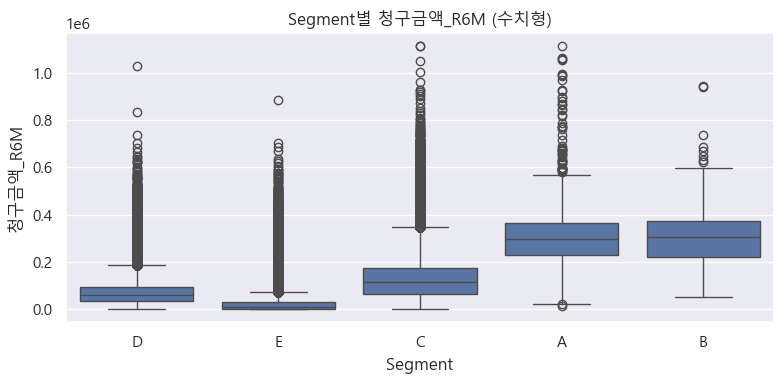

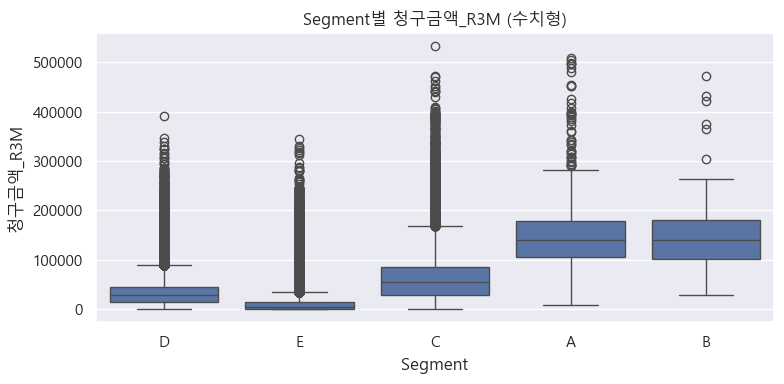

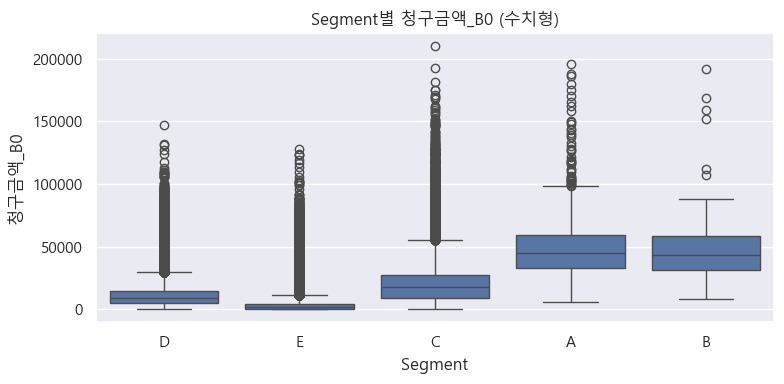

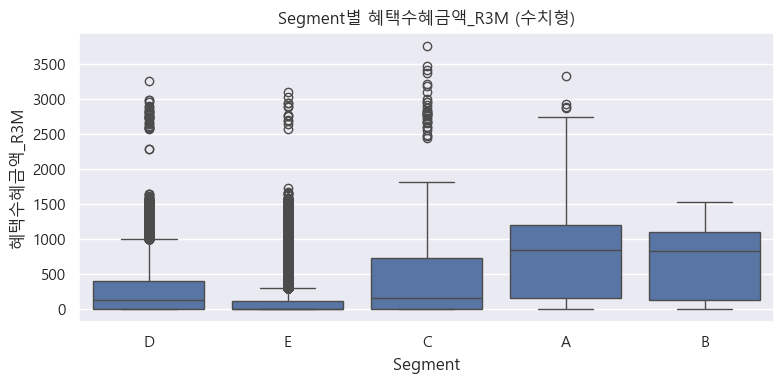

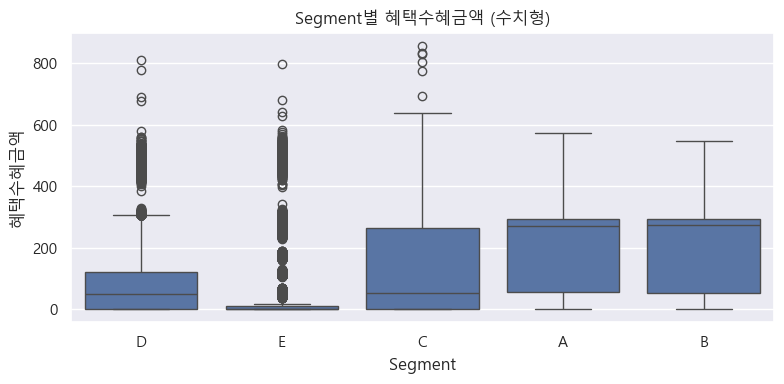

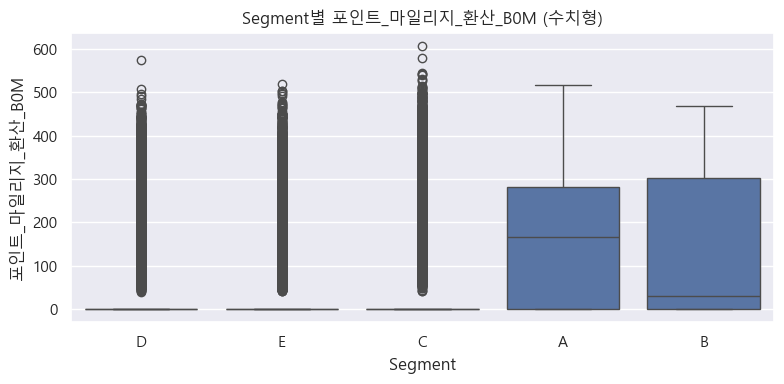

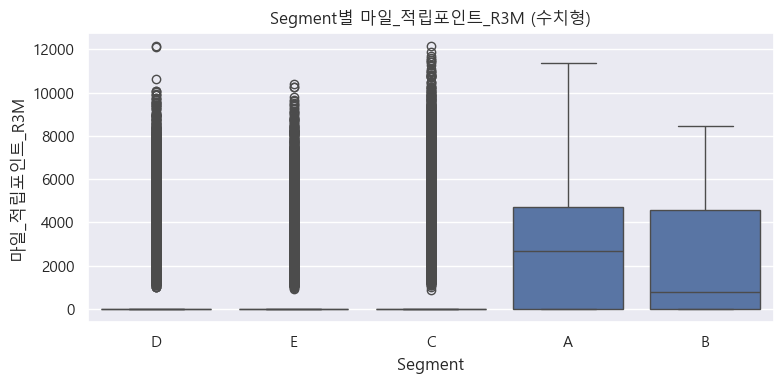

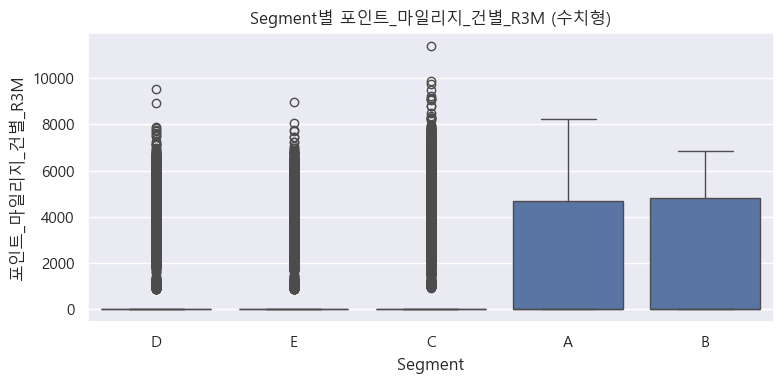

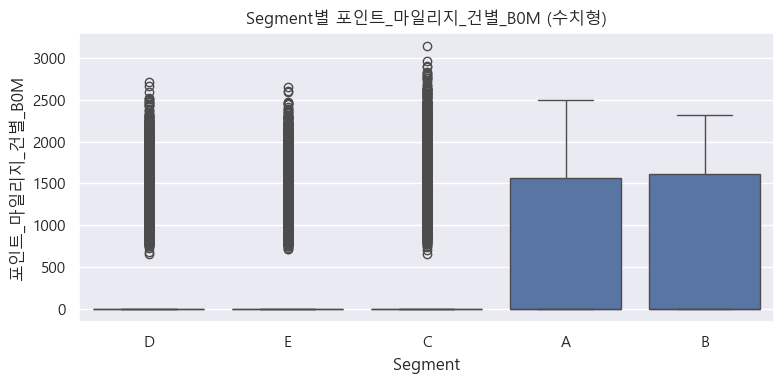

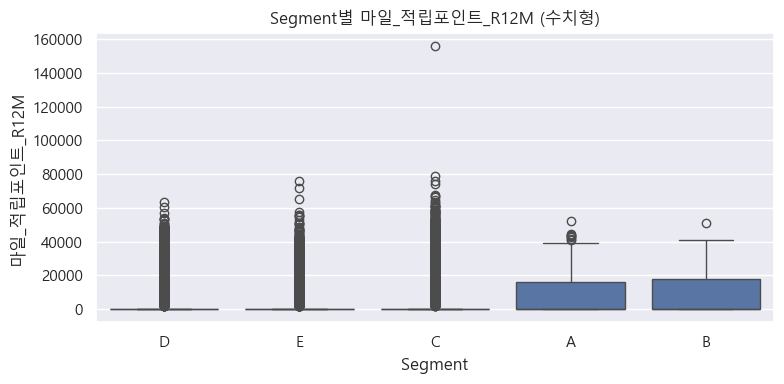

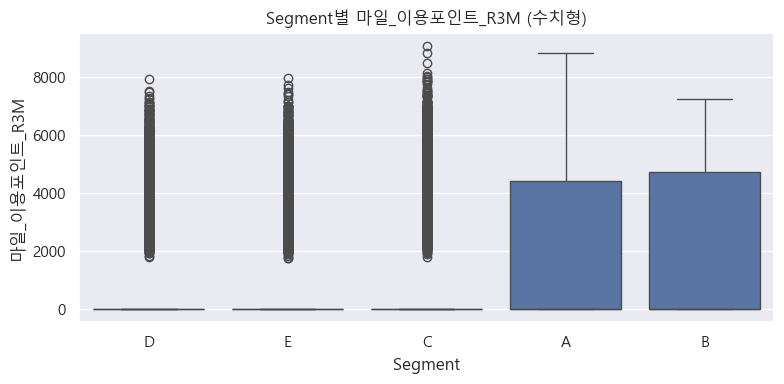

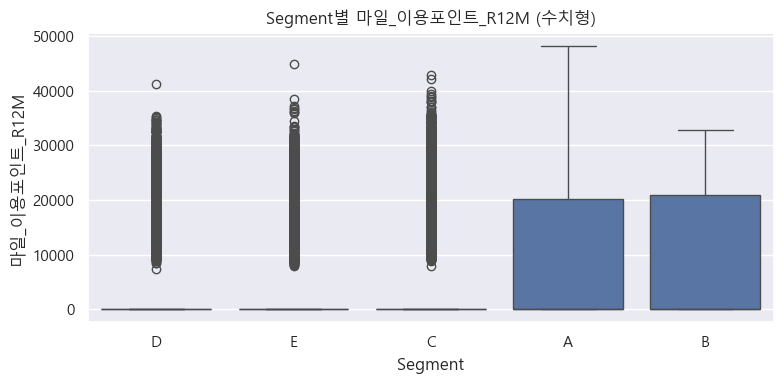

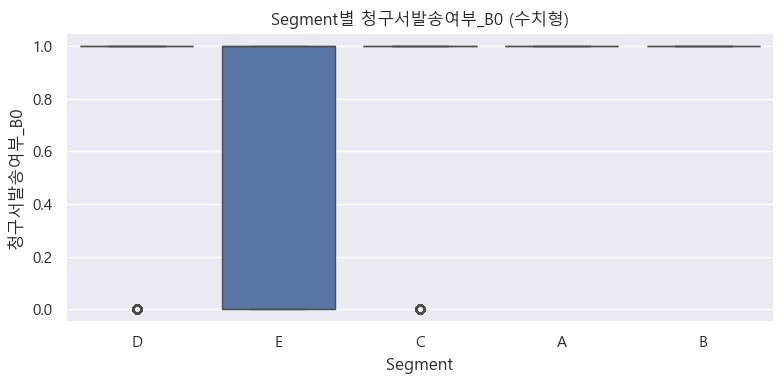

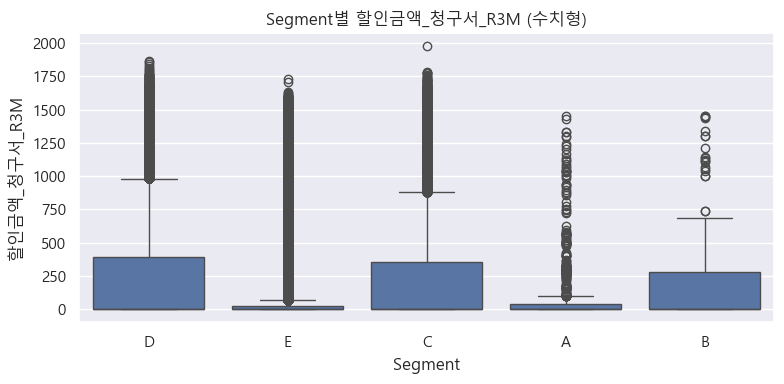

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Segment와 상관 높은 변수 리스트
important_cols = [
    '청구금액_R6M', '청구금액_R3M', '청구금액_B0', '혜택수혜금액_R3M', '혜택수혜금액',
    '포인트_마일리지_환산_B0M', '마일_적립포인트_R3M', '포인트_마일리지_건별_R3M',
    '포인트_마일리지_건별_B0M', '마일_적립포인트_R12M', '마일_이용포인트_R3M',
    '마일_이용포인트_R12M', '청구서발송여부_B0', '할인금액_청구서_R3M'
]

# 수치형, 범주형 자동 분류
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = [col for col in important_cols if col not in numeric_cols]

# 시각화
for col in important_cols:
    plt.figure(figsize=(8, 4))
    
    if col in numeric_cols:
        # 수치형: boxplot
        sns.boxplot(data=train_df, x='Segment', y=col)
        plt.title(f'Segment별 {col} (수치형)')
    else:
        # 범주형: countplot
        sns.countplot(data=train_df, x=col, hue='Segment')
        plt.title(f'{col}별 Segment 분포 (범주형)')
        plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()


In [ ]:
subset = train_df[train_df['기준년월'] == 201811]

In [ ]:
sns.swarmplot(x='Segment', y='청구금액_R6M', data=train_df)
plt.title('Segment별 청구금액 분포 ')
plt.show()


In [ ]:
pivot = train_df.groupby('Segment').mean(numeric_only=True)
sns.heatmap(pivot.T, annot=True, cmap='YlGnBu')
plt.title('Segment 평균값 히트맵')
plt.xlabel('Segment')
plt.ylabel('컬럼')
plt.show()


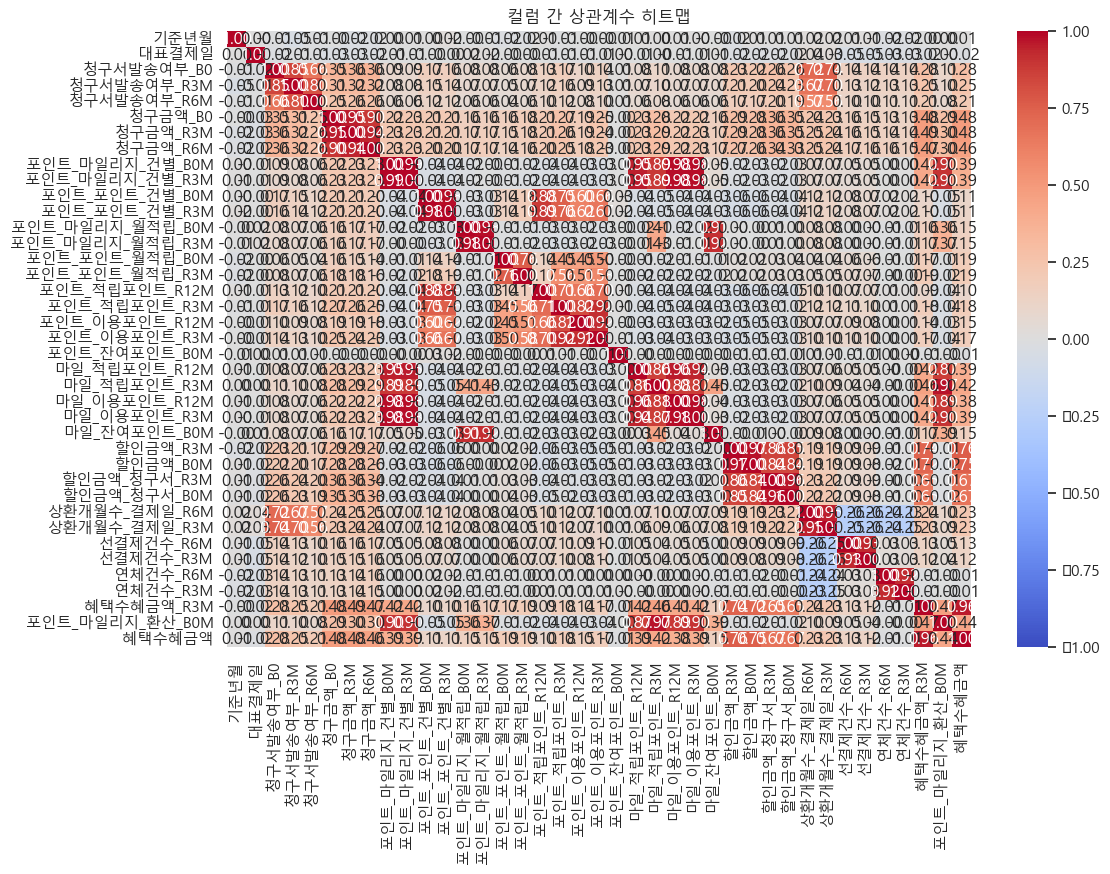

In [36]:
corr = train_df.corr(numeric_only=True)  # 숫자형 컬럼만
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('컬럼 간 상관계수 히트맵')
plt.show()


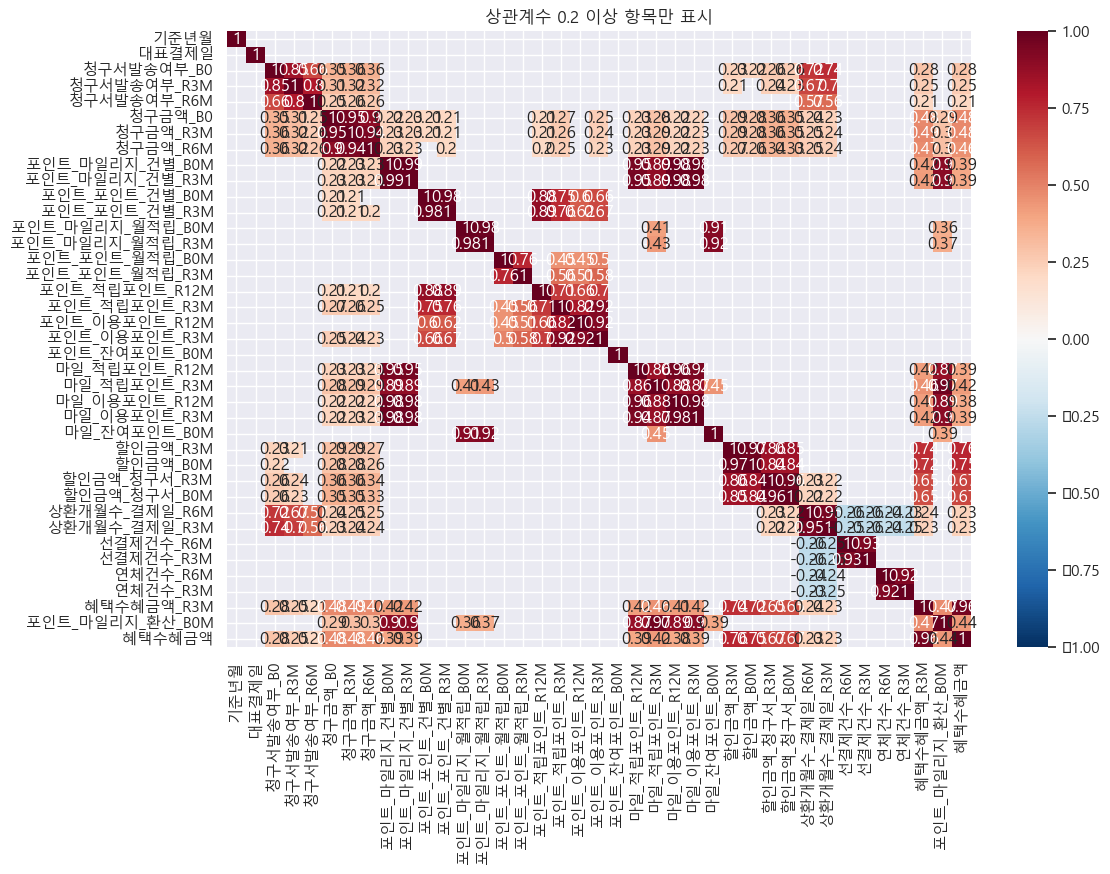

In [38]:
corr = train_df.corr(numeric_only=True)
mask = np.abs(corr) > 0.2  # 상관계수 절대값 기준 필터링
plt.figure(figsize=(12, 8))
sns.heatmap(corr[mask], annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('상관계수 0.2 이상 항목만 표시')
plt.show()
